In [2]:
import pandas as pd

df = pd.read_csv("data/fastfood.csv")

In [3]:
df.head()
df.shape

(21321, 29)

In [54]:
df["Order Placed At"].dtype

dtype('<M8[us]')

In [56]:
sample = df.sample(100, random_state=42)

print(sample)

       Restaurant ID Restaurant name      Subzone       City    Order ID  \
11478       20320607           Swaad     Sector 4  Delhi NCR  6373310321   
12715       21077127     Aura Pizzas   Sector 135  Delhi NCR  6394411509   
12276       20659868     Aura Pizzas     Sector 4  Delhi NCR  6371457965   
2757        21173951     Aura Pizzas  Vasant Kunj  Delhi NCR  6174441975   
9749        21077127     Aura Pizzas   Sector 135  Delhi NCR  6339993445   
...              ...             ...          ...        ...         ...   
16414       20659868     Aura Pizzas     Sector 4  Delhi NCR  6483258818   
15227       20882652     Aura Pizzas  DLF Phase 1  Delhi NCR  6436054860   
4679        20659868     Aura Pizzas     Sector 4  Delhi NCR  6252337797   
6685        21077127     Aura Pizzas   Sector 135  Delhi NCR  6279803539   
6093        20659868     Aura Pizzas     Sector 4  Delhi NCR  6279703455   

          Order Placed At Order Status         Delivery Distance  \
11478 2024-11-23 12

In [4]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  str    
 2   Subzone                                             21321 non-null  str    
 3   City                                                21321 non-null  str    
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  str    
 6   Order Status                                        21321 non-null  str    
 7   Delivery                                            21321 non-null  str    
 8   Distance                                            21321 non-null  str    
 9   Items 

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


Items in order ser viktig ut men stökig, kolla mer noga:

In [6]:
df["Items in order"].head(20)

0     1 x Grilled Chicken Jamaican Tender, 1 x Grill...
1     1 x Peri Peri Fries, 1 x Fried Chicken Angara ...
2                 1 x Bone in Peri Peri Grilled Chicken
3     1 x Fried Chicken Ghostbuster Tender, 1 x Anga...
4     1 x Peri Peri Krispers, 1 x Fried Chicken Anga...
5     1 x Grilled Chicken Jamaican Tangdi, 1 x Bone ...
6                  1 x Bone in Jamaican Grilled Chicken
7                    1 x Bone in Angara Grilled Chicken
8      1 x Fried Chicken Angara Tender, 1 x Angara Rice
9                  1 x Grilled Chicken Peri Peri Tangdi
10                 1 x Bone in Jamaican Grilled Chicken
11                 1 x Bone in Jamaican Grilled Chicken
12                1 x Bone in Smoky Bbq Grilled Chicken
13                   1 x Fried Chicken Peri Peri Tender
14    2 x Tipsy Tiger Ginger Ale, 1 x Bone in Jamaic...
15                   1 x Bone in Angara Grilled Chicken
16                   1 x Fried Chicken Peri Peri Tender
17                             1 x Angara Aloo T

In [7]:
print(df["Items in order"].iloc[0])

1 x Grilled Chicken Jamaican Tender, 1 x Grilled Chicken Peri Peri Tangdi


In [8]:
df_raw = df.copy()

Göra lite EDA. Börjar med kolla efter dubletter och NaN

In [9]:
df["Order ID"].duplicated().sum()

np.int64(0)

In [10]:
df.isna().sum().sort_values(ascending=False)

Restaurant penalty (Rejection)                        21318
Restaurant compensation (Cancellation)                21188
Cancellation / Rejection reason                       21135
Review                                                21025
Customer complaint tag                                20852
Instructions                                          20601
Rating                                                18830
Discount construct                                     5498
KPT duration (minutes)                                  295
Rider wait time (minutes)                               168
Restaurant ID                                             0
Gold discount                                             0
Order Ready Marked                                        0
Total                                                     0
Brand pack discount                                       0
Restaurant discount (Promo)                               0
Restaurant discount (Flat offs, Freebies

In [11]:
df = df.dropna(subset=[
    "KPT duration (minutes)",
    "Rider wait time (minutes)"
])

Tar bort rader som saknas i vettiga kolumner. Nu kika på distance som nog bör vara en float.

In [12]:
df["Distance"].sample(20, random_state=42)

11478    4km
12715    1km
12276    3km
2757     1km
9749     1km
14844    1km
19860    8km
13026    4km
17361    6km
12245    1km
14641    1km
1863     4km
6370     7km
2090     4km
2339     2km
19635    1km
14957    2km
9951     2km
4385     1km
6631     3km
Name: Distance, dtype: str

Lätt att göra numeriskt distance.

In [13]:
df["distance_km"] = df["Distance"].str.replace("km", "", regex=False).astype(int)

ValueError: invalid literal for int() with base 10: '<1'

In [14]:
import numpy as np

df["distance_km"] = (
    df["Distance"]
    .str.replace("km", "", regex=False)
    .str.replace("<1", "0.5", regex=False)
)

df["distance_km"] = pd.to_numeric(df["distance_km"], errors="coerce")

In [16]:
df["distance_km"].describe()

count    20963.000000
mean         4.169513
std          2.994584
min          0.500000
25%          2.000000
50%          3.000000
75%          6.000000
max         21.000000
Name: distance_km, dtype: float64

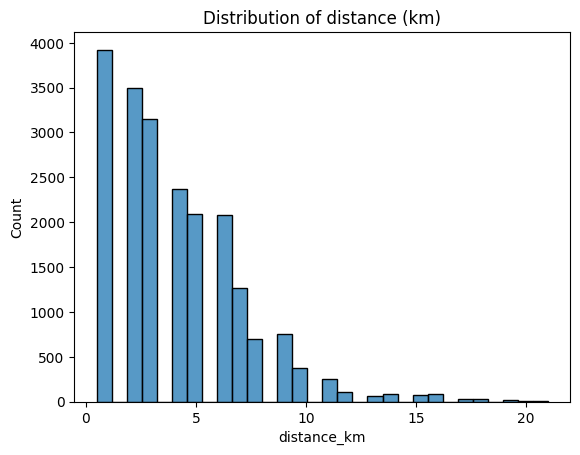

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["distance_km"], bins=30)
plt.title("Distribution of distance (km)")
plt.show()

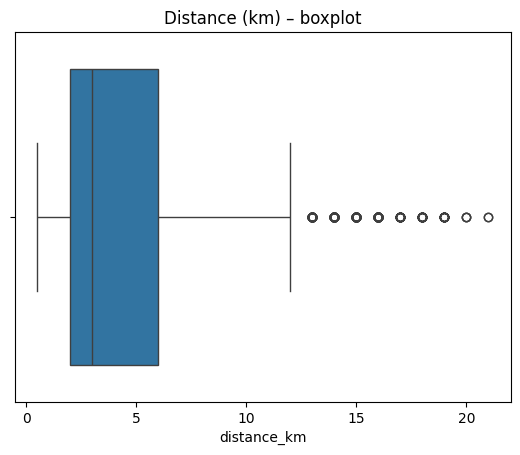

In [18]:
sns.boxplot(x=df["distance_km"])
plt.title("Distance (km) – boxplot")
plt.show()

In [22]:
df[df["distance_km"] > 15][
    ["distance_km", "Total", "City"]
].head(20)

,distance_km,Total,City
641,16.0,1657.37,Delhi NCR
683,16.0,1110.90,Delhi NCR
702,16.0,691.95,Delhi NCR
774,17.0,1211.70,Delhi NCR
800,17.0,1282.05,Delhi NCR
956,18.0,534.45,Delhi NCR
1009,17.0,889.35,Delhi NCR
1155,17.0,984.90,Delhi NCR
1228,16.0,1195.95,Delhi NCR
1956,19.0,1676.85,Delhi NCR


Outliers, men förmodligen kommer de kunna säga något om datan att en liten del beställningar är på långt avstånd så jag behåller.
Låt oss kolla om folk beställer mer om de är långt bort.

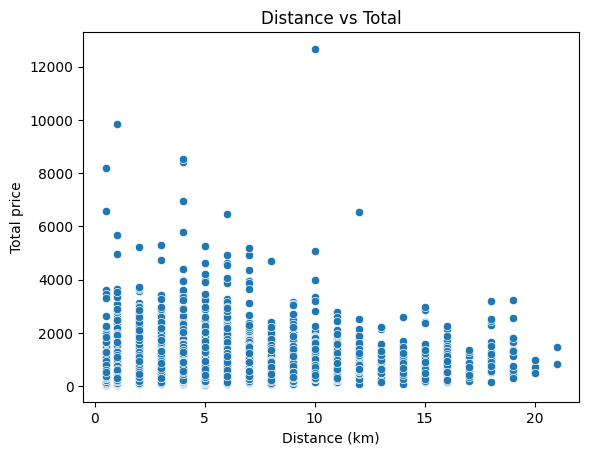

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df["distance_km"], y=df["Total"])
plt.title("Distance vs Total")
plt.xlabel("Distance (km)")
plt.ylabel("Total price")
plt.show()

In [24]:
df["distance_bucket"] = pd.cut(
    df["distance_km"],
    bins=[0, 2, 5, 10, 25],
    labels=["0-2km", "2-5km", "5-10km", "10km+"]
)

In [25]:
df.groupby("distance_bucket")["Total"].mean()

distance_bucket
0-2km     648.423785
2-5km     661.974009
5-10km    730.256063
10km+     890.263938
Name: Total, dtype: float64

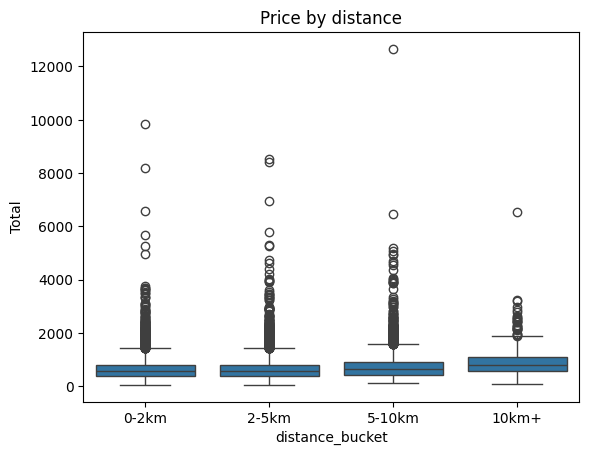

In [26]:
sns.boxplot(x="distance_bucket", y="Total", data=df)
plt.title("Price by distance")
plt.show()

Några sjuka priser, ska kolla om de innehåller sjukt mycket mat eller är fel. Så måste göra Items numerisk.


In [28]:
import re

def extract_num_items(text):
    if pd.isna(text):
        return 0
    numbers = re.findall(r"(\d+)\s*x", text)
    return sum(map(int, numbers))

df["num_items"] = df["Items in order"].apply(extract_num_items)

In [29]:
df[["Items in order", "num_items"]].head(10)

,Items in order,num_items
0,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",2
1,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",3
2,1 x Bone in Peri Peri Grilled Chicken,1
3,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",2
4,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",2
5,"1 x Grilled Chicken Jamaican Tangdi, 1 x Bone ...",2
6,1 x Bone in Jamaican Grilled Chicken,1
7,1 x Bone in Angara Grilled Chicken,1
8,"1 x Fried Chicken Angara Tender, 1 x Angara Rice",2
9,1 x Grilled Chicken Peri Peri Tangdi,1


In [30]:
df.sort_values("Total", ascending=False)[
    ["Total", "num_items", "distance_km", "Items in order"]
].head(10)

,Total,num_items,distance_km,Items in order
8092,12663.00,20,10.0,"10 x All About Chicken Pizza, 10 x Makhani Pan..."
19221,9853.67,29,1.0,"8 x Tipsy Tiger Ginger Ale, 2 x Peri Peri Pane..."
15329,8536.50,20,4.0,"5 x Peri Peri Grilled Chicken Pizza, 5 x Makha..."
8059,8424.15,10,4.0,"1 x Bellpepper Onion Pizza, 3 x Peri Peri Gril..."
15144,8176.35,26,0.5,26 x Bageecha Pizza
10379,6939.45,11,4.0,"2 x Bageecha Pizza, 2 x Mutton Seekh Pizza, 2 ..."
7674,6575.94,12,0.5,"4 x Chilli Cheese Garlic Bread, 2 x Peri Peri ..."
7969,6531.00,10,12.0,"1 x All About Chicken Pizza, 2 x Margherita Pi..."
20611,6470.10,12,6.0,"2 x Fried Chicken Tenders, 2 x Grilled Chicken..."
10985,5777.10,14,4.0,"7 x Bageecha Pizza, 7 x Angara Paneer Melt"


Verkar inte fel på datan, några har bara köpt en jävla massa mat på några få ordrar! Men beställer man mer om man bor långt bort?

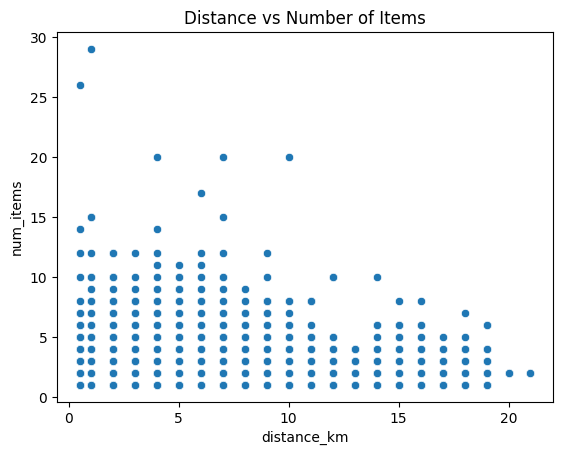

In [31]:
sns.scatterplot(x=df["distance_km"], y=df["num_items"])
plt.title("Distance vs Number of Items")
plt.show()

Nej ser snarare ut som man beställer färre ju längre bort man är, underligt.

In [32]:
df.groupby("distance_bucket")["num_items"].mean()

distance_bucket
0-2km     1.864512
2-5km     1.907910
5-10km    2.036901
10km+     2.250338
Name: num_items, dtype: float64

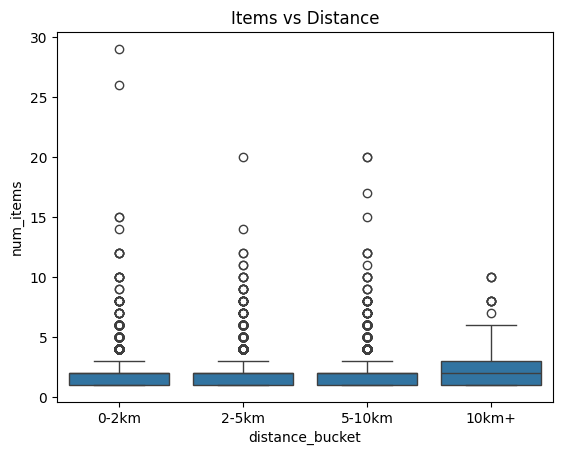

In [33]:
import seaborn as sns

sns.boxplot(x="distance_bucket", y="num_items", data=df)
plt.title("Items vs Distance")
plt.show()

Här kan man nog hitta mönster. Undersöker mina sista (vad jag tror) viktiga variablar, tid.

In [34]:
df[[
    "KPT duration (minutes)",
    "Rider wait time (minutes)"
]].describe()

,KPT duration (minutes),Rider wait time (minutes)
count,20963.000000,20963.000000
mean,17.331996,4.816663
std,6.274248,4.973239
min,0.020000,0.100000
25%,13.380000,1.000000
50%,16.330000,3.100000
75%,20.050000,7.400000
max,90.870000,73.800000


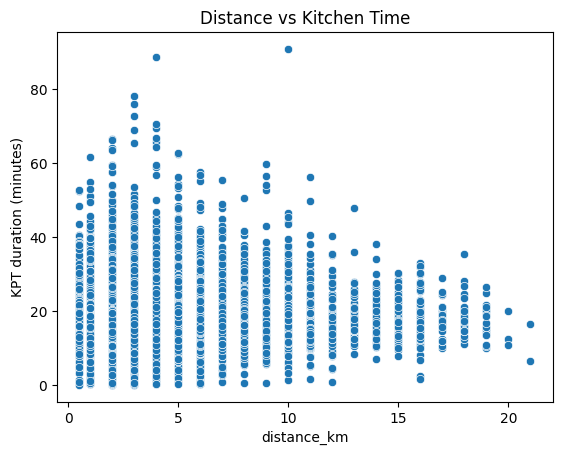

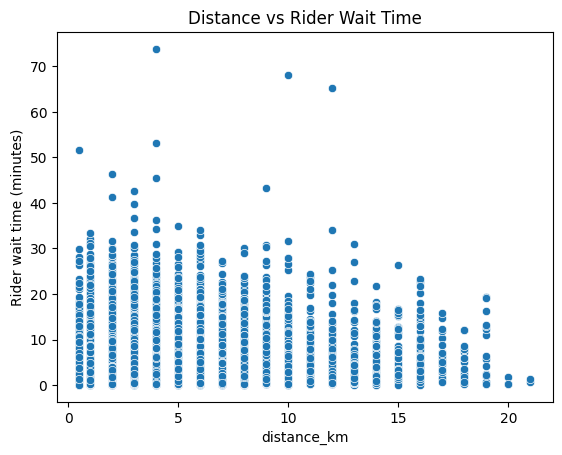

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=df["distance_km"],
    y=df["KPT duration (minutes)"]
)
plt.title("Distance vs Kitchen Time")
plt.show()

sns.scatterplot(
    x=df["distance_km"],
    y=df["Rider wait time (minutes)"]
)
plt.title("Distance vs Rider Wait Time")
plt.show()

In [36]:
df["Customer ID"].nunique()

11488


Kollar hur många unika kunder det finns

In [37]:
orders_per_customer = df["Customer ID"].value_counts()

# hur många är engångskunder
single_orders = (orders_per_customer == 1).sum()

# andel
single_orders / len(orders_per_customer)

np.float64(0.6670438718662952)

Sista steg för att städa vettiga variablar, fixa tider. Tex tid på dygnet som ordrar görs.

In [40]:
df["Order Placed At"].head(20)

0    2024-09-10 23:38:00
1    2024-09-10 23:34:00
2    2024-09-10 15:52:00
3    2024-09-10 15:45:00
4    2024-09-10 15:04:00
5    2024-09-10 12:28:00
6    2024-09-10 00:03:00
7    2024-09-09 22:54:00
8    2024-09-09 22:51:00
9    2024-09-09 15:22:00
10   2024-09-08 22:03:00
11   2024-09-08 21:49:00
12   2024-09-08 19:48:00
13   2024-09-08 19:48:00
14   2024-09-08 19:21:00
15   2024-09-08 18:33:00
16   2024-09-08 15:23:00
17   2024-09-08 02:55:00
18   2024-09-08 02:23:00
19   2024-09-08 01:57:00
Name: Order Placed At, dtype: datetime64[us]

In [41]:
df["order_hour"] = df["Order Placed At"].dt.hour

In [43]:
df.groupby("order_hour")["Total"].mean()

order_hour
0     631.826476
1     617.406227
2     612.595021
3     605.490789
4     468.825000
11    783.501967
12    645.710495
13    629.393315
14    628.040803
15    644.678298
16    620.547180
17    627.782025
18    702.093858
19    761.831625
20    745.337788
21    708.658539
22    674.294470
23    661.017941
Name: Total, dtype: float64

In [44]:
df.groupby("order_hour")["num_items"].mean()

order_hour
0     1.718519
1     1.744760
2     1.733471
3     1.650000
4     1.500000
11    2.236667
12    1.962838
13    1.913978
14    1.892963
15    1.869297
16    1.858427
17    1.916905
18    1.979760
19    2.101382
20    2.049653
21    1.953499
22    1.912565
23    1.856254
Name: num_items, dtype: float64

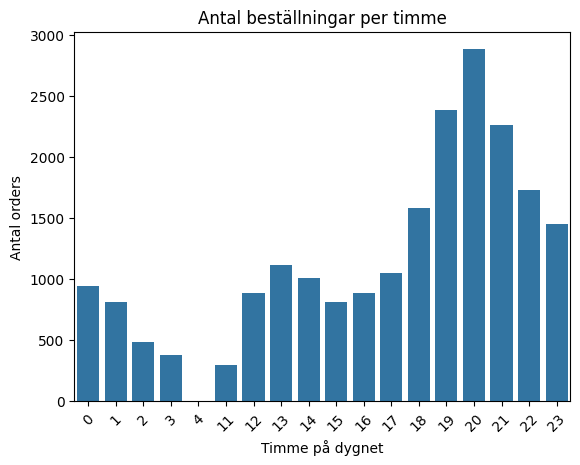

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="order_hour", data=df)
plt.title("Antal beställningar per timme")
plt.xlabel("Timme på dygnet")
plt.ylabel("Antal orders")
plt.xticks(rotation=45)
plt.show()

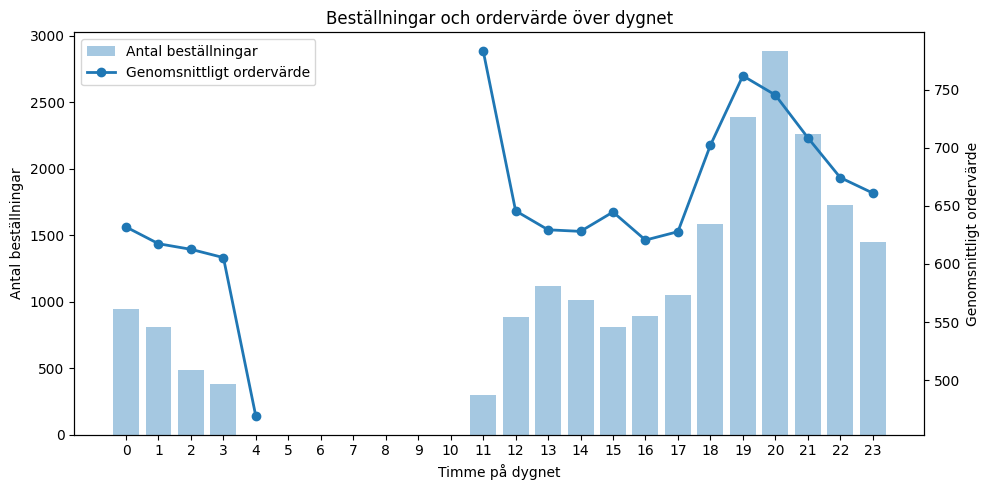

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregera per timme
hourly = df.groupby("order_hour").agg(
    antal_orders=("Order ID", "count"),
    genomsnittligt_ordervarde=("Total", "mean")
)

# Se till att alla timmar 0–23 finns med
hourly = hourly.reindex(range(24))

# Om inga orders finns en timme: antal orders = 0
hourly["antal_orders"] = hourly["antal_orders"].fillna(0)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Staplar: antal orders
bars = ax1.bar(
    hourly.index,
    hourly["antal_orders"],
    alpha=0.4,
    label="Antal beställningar"
)

ax1.set_xlabel("Timme på dygnet")
ax1.set_ylabel("Antal beställningar")
ax1.set_xticks(range(24))

# Linje: genomsnittligt ordervärde
ax2 = ax1.twinx()

line = ax2.plot(
    hourly.index,
    hourly["genomsnittligt_ordervarde"],
    marker="o",
    linewidth=2,
    label="Genomsnittligt ordervärde"
)

ax2.set_ylabel("Genomsnittligt ordervärde")

# Gemensam legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.title("Beställningar och ordervärde över dygnet")
plt.tight_layout()
plt.show()

In [51]:
df[df["order_hour"] == 11][["Total"]].describe()

,Total
count,300.000000
mean,783.501967
std,1109.193800
min,145.950000
25%,365.400000
50%,554.925000
75%,783.825000
max,12663.000000


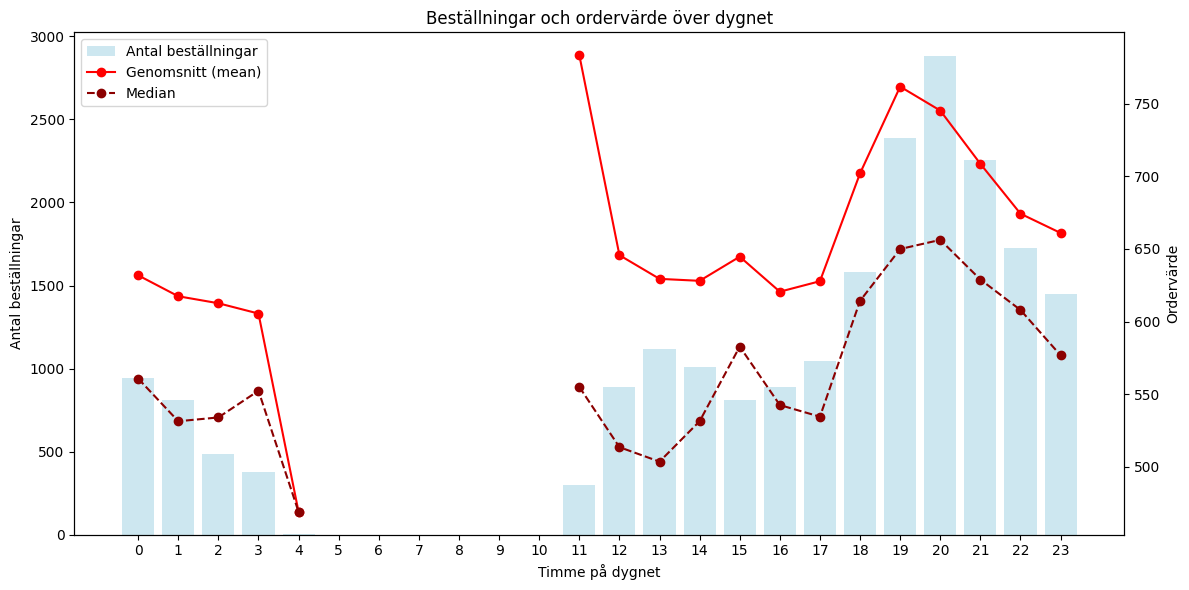

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Aggregera data per timme
hourly = df.groupby("order_hour").agg(
    antal_orders=("Order ID", "count"),
    mean_price=("Total", "mean"),
    median_price=("Total", "median")
)

# Se till att alla timmar 0–23 finns med
hourly = hourly.reindex(range(24))

# Sätt antal orders = 0 där det saknas
hourly["antal_orders"] = hourly["antal_orders"].fillna(0)

# --- PLOTT ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Staplar: antal orders
ax1.bar(
    hourly.index,
    hourly["antal_orders"],
    color="lightblue",
    alpha=0.6,
    label="Antal beställningar"
)

ax1.set_xlabel("Timme på dygnet")
ax1.set_ylabel("Antal beställningar")
ax1.set_xticks(range(24))

# Andra axeln: pris
ax2 = ax1.twinx()

# Mean (påverkas av outliers)
ax2.plot(
    hourly.index,
    hourly["mean_price"],
    color="red",
    marker="o",
    label="Genomsnitt (mean)"
)

# Median (robust)
ax2.plot(
    hourly.index,
    hourly["median_price"],
    color="darkred",
    linestyle="--",
    marker="o",
    label="Median"
)

ax2.set_ylabel("Ordervärde")

# Gemensam legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left"
)

plt.title("Beställningar och ordervärde över dygnet")
plt.tight_layout()
plt.show()

Beställningsbeteendet är tydligt kopplat till tid på dygnet, med toppar under lunch och framför allt kväll.
Enstaka stora beställningar, som exempelvis vid kl. 11, påverkar genomsnittet kraftigt. Dessa observationer är sannolikt korrekta men gör medelvärdet mindre robust, vilket motiverar att även använda median för att få en mer stabil bild.

Redo för min första K-means. Sätter några variablar i en första version.

In [53]:
features = [
    "Total",                      # spendering
    "num_items",                  # orderstorlek
    "distance_km",                # avstånd
    "KPT duration (minutes)",     # tillagning
    "Rider wait time (minutes)"   # leveransfriktion
]

In [57]:
df_model = df[features].dropna().copy()

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

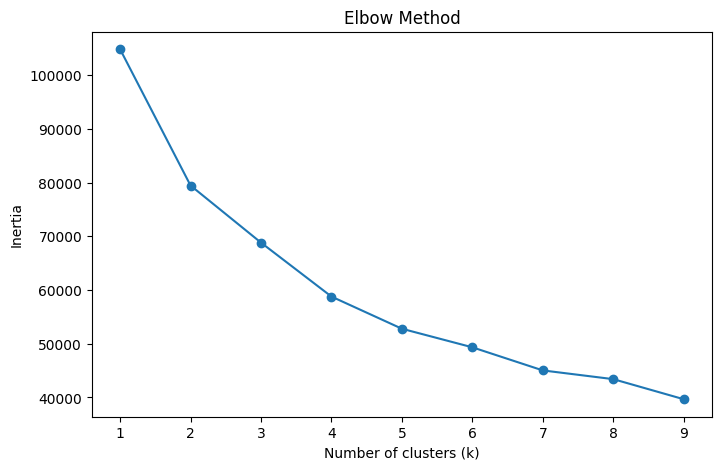

In [59]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [60]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_model["cluster"] = clusters

In [61]:
df_model.groupby("cluster").mean()

,Total,num_items,distance_km,KPT duration (minutes),Rider wait time (minutes)
cluster,,,,,
0,1523.592276,4.245968,4.453181,22.701340,5.636694
1,521.526691,1.536977,2.663604,14.722659,2.761573
2,656.098776,1.776190,8.148299,16.010007,3.746100
3,675.007378,1.901719,3.633954,23.666473,12.022837


In [62]:
df_model["cluster"] = clusters
df_model["order_hour"] = df.loc[df_model.index, "order_hour"]

df_model.groupby("cluster")["order_hour"].mean()

cluster
0    16.983871
1    16.212630
2    16.114286
3    15.832092
Name: order_hour, dtype: float64

In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

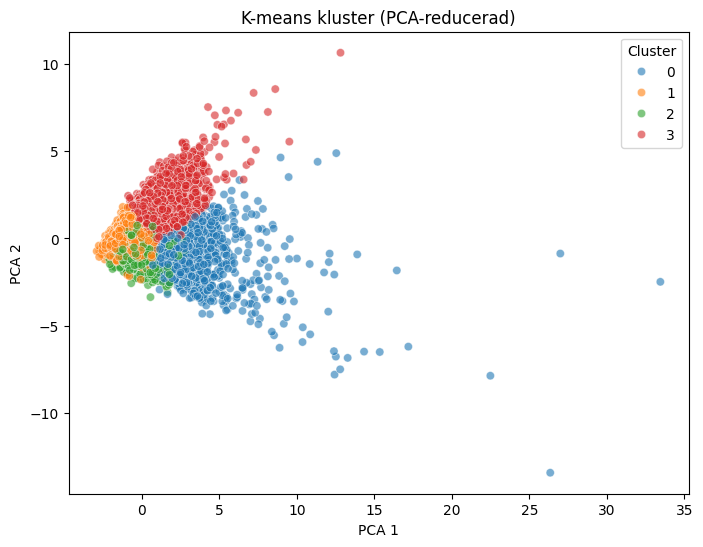

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_model["cluster"],
    palette="tab10",
    alpha=0.6
)

plt.title("K-means kluster (PCA-reducerad)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()

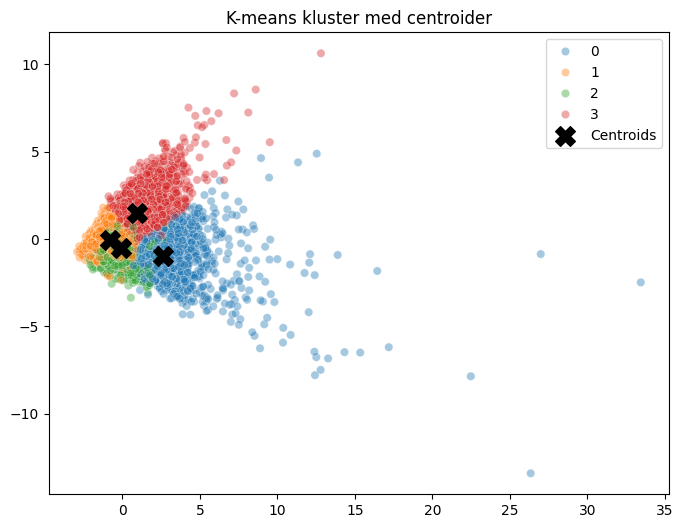

In [65]:
centroids = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_model["cluster"],
    palette="tab10",
    alpha=0.4
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="black",
    s=200,
    marker="X",
    label="Centroids"
)

plt.legend()
plt.title("K-means kluster med centroider")
plt.show()

Klustren är inte helt separerade i 2D, men visar ändå tydliga tendenser, särskilt för de mer extrema beteendena.

In [66]:
cluster_names = {
    0: "Large orders",
    1: "Small local orders",
    2: "Long distance",
    3: "High delay orders"
}

df_model["cluster_name"] = df_model["cluster"].map(cluster_names)

In [68]:
df_model["cluster_name"] = df_model["cluster"].map(cluster_names)

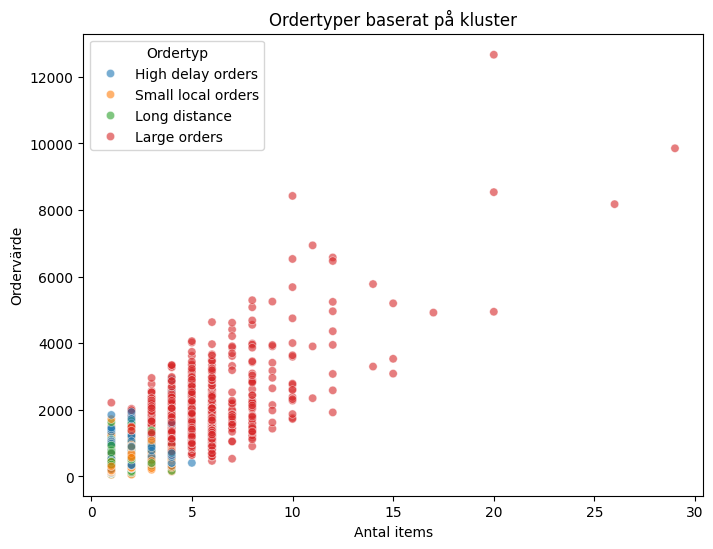

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_model,
    x="num_items",
    y="Total",
    hue="cluster_name",
    palette="tab10",
    alpha=0.6
)

plt.title("Ordertyper baserat på kluster")
plt.xlabel("Antal items")
plt.ylabel("Ordervärde")
plt.legend(title="Ordertyp")
plt.show()

In [71]:
df["weekday_num"] = df["Order Placed At"].dt.dayofweek

In [72]:
df["day_type"] = df["weekday_num"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [73]:
df["day_type"].value_counts()

day_type
Weekday    14170
Weekend     6793
Name: count, dtype: int64

In [74]:
df.groupby("day_type")["Total"].mean()

day_type
Weekday    667.883432
Weekend    711.699789
Name: Total, dtype: float64

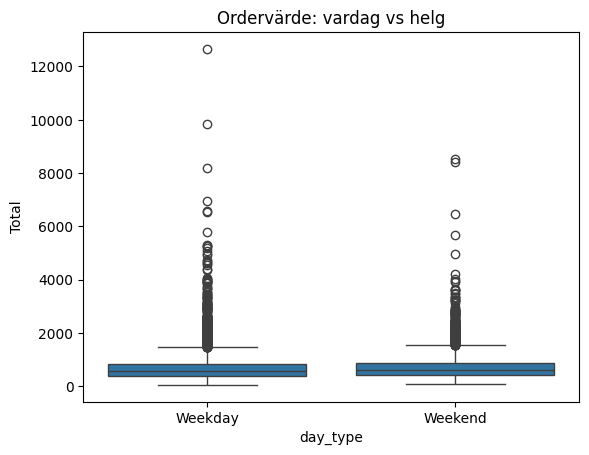

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x="day_type",
    y="Total"
)

plt.title("Ordervärde: vardag vs helg")
plt.show()

In [76]:
df_model["day_type"] = df.loc[df_model.index, "day_type"]

df_model.groupby(["cluster_name", "day_type"]).size().unstack()

day_type,Weekday,Weekend
cluster_name,,
High delay orders,2365,1125
Large orders,1424,808
Long distance,2966,1444
Small local orders,7415,3416


BIAS pga fler vardagar på en vecka.

In [78]:
df_model.groupby(["cluster_name", "day_type"]).size().unstack().div(
    df_model.groupby("cluster_name").size(), axis=0
)

day_type,Weekday,Weekend
cluster_name,,
High delay orders,0.677650,0.322350
Large orders,0.637993,0.362007
Long distance,0.672562,0.327438
Small local orders,0.684609,0.315391


Veckodag verkar inte vara en drivande faktor för vilken typ av beställning som görs, vilket tyder på att beteendemönstren är relativt stabila över tid